In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../Data/Reviews.csv")

In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.shape

(568454, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [6]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [7]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [8]:
df['Score']

0         5
1         1
2         4
3         2
4         5
         ..
568449    5
568450    2
568451    5
568452    5
568453    5
Name: Score, Length: 568454, dtype: int64

In [9]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

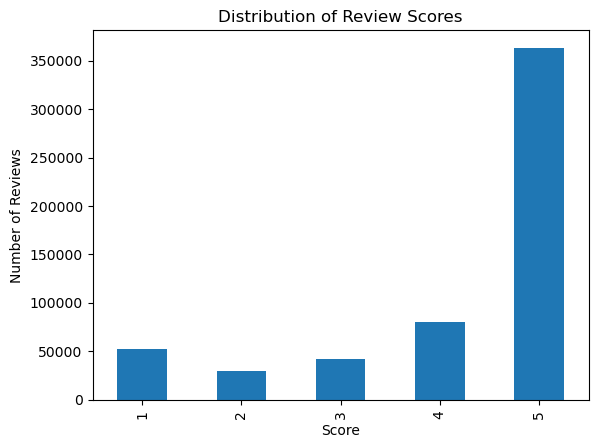

In [10]:
import matplotlib.pyplot as plt

df['Score'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")

plt.show()

In [11]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [12]:
df = df[['Score', 'Text']]

In [13]:
df.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


In [14]:
def sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [15]:
sentiment(1)

'Negative'

In [16]:
sentiment(5)

'Positive'

In [17]:
df['Sentiment'] = df['Score'].apply(sentiment)

In [18]:
df = df.sample(50000, random_state=42)

In [19]:
df.shape

(50000, 3)

In [20]:
df['Text'] = df['Text'].str.lower()

In [21]:
df['Text'].head()

165256    having tried a couple of other brands of glute...
231465    my cat loves these treats. if ever i can't fin...
427827    a little less than i expected.  it tends to ha...
433954    first there was frosted mini-wheats, in origin...
70260     and i want to congratulate the graphic artist ...
Name: Text, dtype: object

In [22]:
import string

In [23]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [24]:
df['Text'] = df['Text'].str.translate(
    str.maketrans('', '', string.punctuation)
)

In [25]:
df['Text'].head()

165256    having tried a couple of other brands of glute...
231465    my cat loves these treats if ever i cant find ...
427827    a little less than i expected  it tends to hav...
433954    first there was frosted miniwheats in original...
70260     and i want to congratulate the graphic artist ...
Name: Text, dtype: object

In [26]:
from nltk.corpus import stopwords

In [27]:
stop_words = set(stopwords.words('english'))

In [28]:
len(stop_words)

198

In [29]:
df['Text'] = df['Text'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [30]:
df['Text'].head()

165256    tried couple brands glutenfree sandwich cookie...
231465    cat loves treats ever cant find house pop top ...
427827    little less expected tends muddy taste expecte...
433954    first frosted miniwheats original size frosted...
70260     want congratulate graphic artist putting entir...
Name: Text, dtype: object

In [31]:
review = "This product is absolutely amazing"

for word in review.split():
    if word.lower() not in stop_words:
        print(word)

product
absolutely
amazing


In [32]:
df['Text'] = df['Text'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [34]:
tfidf = TfidfVectorizer(max_features=5000)

In [35]:
TfidfVectorizer()

TfidfVectorizer()

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

In [37]:
X = tfidf.fit_transform(df['Text'])

In [39]:
X.shape

(50000, 5000)

In [40]:
y = df['Sentiment']

In [41]:
y.head()

165256    Positive
231465    Positive
427827     Neutral
433954    Negative
70260     Positive
Name: Sentiment, dtype: object

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
X_train.shape, X_test.shape

((40000, 5000), (10000, 5000))

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression(max_iter=1000)

In [47]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [48]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [49]:
y_pred = model.predict(X_test)

In [50]:
y_pred[:10]

array(['Positive', 'Negative', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Positive'],
      dtype=object)

In [51]:
from sklearn.metrics import accuracy_score

In [52]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.8526


In [53]:
from sklearn.metrics import confusion_matrix

In [54]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 817   37  551]
 [ 150  100  544]
 [ 145   47 7609]]


In [55]:
from sklearn.metrics import classification_report

In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.73      0.58      0.65      1405
     Neutral       0.54      0.13      0.20       794
    Positive       0.87      0.98      0.92      7801

    accuracy                           0.85     10000
   macro avg       0.72      0.56      0.59     10000
weighted avg       0.83      0.85      0.83     10000



In [58]:
review = "This coffee tastes fantastic. I loved it."

In [59]:
# Convert to lowercase
review = review.lower()

# Remove punctuation
import string
review = review.translate(str.maketrans('', '', string.punctuation))

# Remove stop words
review = ' '.join(
    word for word in review.split()
    if word not in stop_words
)

# Convert to TF-IDF
review_vector = tfidf.transform([review])

# Predict
prediction = model.predict(review_vector)

print("Review:", review)
print("Predicted Sentiment:", prediction[0])

Review: coffee tastes fantastic loved
Predicted Sentiment: Positive


In [60]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [61]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Sentiment_Analysis.ipynb',
 'sentiment_model.pkl',
 'tfidf_vectorizer.pkl']